# Importação de Bibliotecas

In [ ]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import max_error

# Importação de Banco de Dados

In [ ]:
# Exportar Dataset
df = pd.read_csv('https://docs.google.com/spreadsheets/d/14GjwAZoqXbdEv_l3WWpCqSQv1A9imODE/export?format=csv')

# Tratação de Dados

In [ ]:
# Verificando as informações do Dataset
print("Informações Dataset")
df.info()

# Verificando a existência de valores nulos
print("\nExistência de Nulos")
df.isnull().sum()


Informações Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113634 entries, 0 to 113633
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Iso3_code            113634 non-null  object
 1   Country              113634 non-null  object
 2   Region               113634 non-null  object
 3   Subregion            113634 non-null  object
 4   Indicator            113634 non-null  object
 5   Dimension            113634 non-null  object
 6   Category             113634 non-null  object
 7   Sex                  113634 non-null  object
 8   Age                  113634 non-null  object
 9   Year                 113634 non-null  int64 
 10  Unit of measurement  113634 non-null  object
 11  VALUE                113634 non-null  object
 12  Source               113634 non-null  object
dtypes: int64(1), object(12)
memory usage: 11.3+ MB

Existência de Nulos


,0
Iso3_code,0
Country,0
Region,0
Subregion,0
Indicator,0
Dimension,0
Category,0
Sex,0
Age,0
Year,0


In [ ]:

# Retirando colunas inúteis
colunas_inuteis = ['Iso3_code', 'Source']
novo_df = df.drop(columns=colunas_inuteis, errors='ignore')

#Concentrando apenas nas vítimas de homicidio
novo_df = novo_df[novo_df['Indicator'] == 'Victims of intentional homicide']

# Converter vírgula em ponto ANTES de transformar VALUE em número
novo_df['VALUE'] = novo_df['VALUE'].astype(str).str.replace(',', '.')

# Converter os dados em VALUE para o tipo númerico
novo_df['VALUE'] = pd.to_numeric(novo_df['VALUE'], errors='coerce')

# Mostrar as cinco primeiras linhas do Dataset
display(novo_df.head())

# Conferir se há algum NaN após transformação
print("Linhas com VALUE NaN (após correção de vírgula): ", novo_df['VALUE'].isnull().sum())

,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE
1308,Aruba,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,1990,Counts,0.0
1309,Anguilla,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,1990,Counts,0.0
1310,Armenia,Asia,Western Asia,Victims of intentional homicide,Total,Total,Total,Total,1990,Counts,178.0
1311,Antigua and Barbuda,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,1990,Counts,1.0
1312,Australia,Oceania,Australia and New Zealand,Victims of intentional homicide,Total,Total,Total,Total,1990,Counts,374.0


Linhas com VALUE NaN (após correção de vírgula):  0


### Preparação para Regressão Linear



In [ ]:
# Nivelamento para obter proporções mais justas
df_taxa= novo_df[novo_df['Unit of measurement'] == 'Rate per 100,000 population']

# Analise da tendencia de homicídios por ano
df_tendencia = df_taxa.groupby('Year')['VALUE'].mean().reset_index()

# Exibir tendência de homicídios por ano
print("-- Tendência de Homicídios por Ano: --")
display(df_tendencia.head())

-- Tendência de Homicídios por Ano: --


,Year,VALUE
0,1990,6.521005
1,1991,7.343551
2,1992,8.096627
3,1993,8.291155
4,1994,9.121937


# Algoritmo de Regressão Linear

In [ ]:
# Divisão dos Dados em foco
X = df_tendencia[['Year']]
y = df_tendencia['VALUE']

In [ ]:
# Criação de Algoritimo de Regressão Linear
regressor_linear = LinearRegression()

#Treinando o modelo
regressor_linear.fit(X, y)

LinearRegression()

In [ ]:
# Criar dados para o futuro
futuro = pd.DataFrame({'Year': [2023, 2024, 2025, 2026]})

# Prever taxas futuras
previsoes = regressor_linear.predict(futuro)
futuro['Taxa Prevista'] = previsoes

# Exibir os resultados
print("--- Previsões da Regressão Linear (2023-2026) ---")
display(futuro)


--- Previsões da Regressão Linear (2023-2026) ---


,Year,Taxa Prevista
0,2023,4.261859
1,2024,4.126228
2,2025,3.990598
3,2026,3.854968


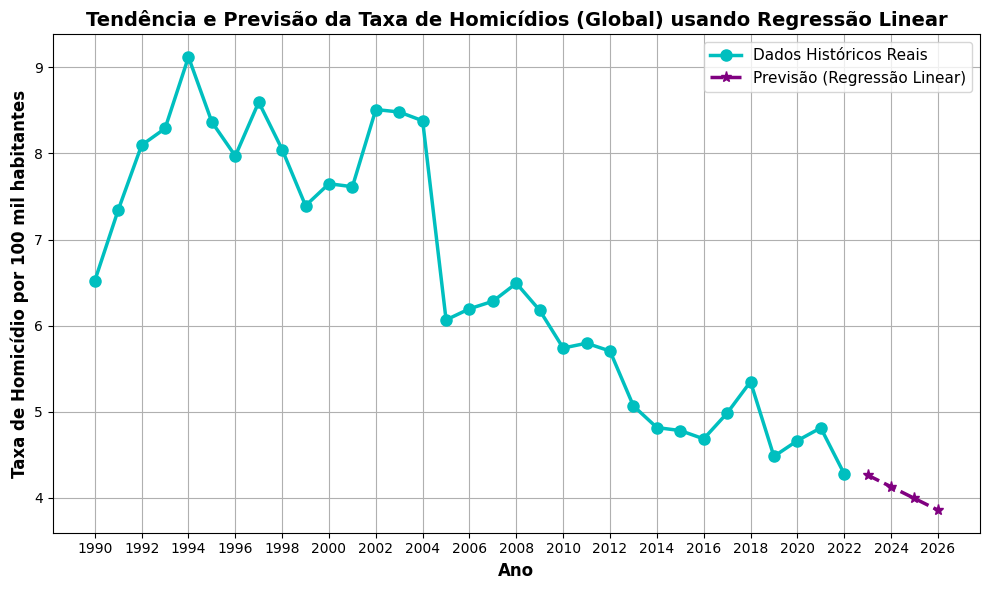

In [ ]:
# Configuração visual de alto contraste
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.axes()
ax.set_facecolor('white')
ax.grid(True)

# Plotando os dados históricos reais
plt.plot(df_tendencia['Year'], df_tendencia['VALUE'],
         marker='o', color='c', linewidth=2.5, markersize=8, label='Dados Históricos Reais')

# Plotando as previsões do modelo
plt.plot(futuro['Year'], futuro['Taxa Prevista'],
         marker='*', color='purple', linewidth=2.5, linestyle='--', markersize=8, label='Previsão (Regressão Linear)')

# Adicionando rótulos e título
plt.title('Tendência e Previsão da Taxa de Homicídios (Global) usando Regressão Linear', fontsize=14, fontweight='bold', color='black')
plt.xlabel('Ano', fontsize=12, fontweight='bold', color='black')
plt.ylabel('Taxa de Homicídio por 100 mil habitantes', fontsize=12, fontweight='bold', color='black')

# Forçando o eixo X a mostrar os anos inteiros e ajustando a legenda
plt.xticks(np.arange(df_tendencia['Year'].min(), 2027, 2))
plt.legend(fontsize=11)

# Exibindo o gráfico
plt.tight_layout()
plt.show()

## 01. Quais países apresentam os 10 maiores índices de homicídios nos últimos 5 anos?

In [ ]:
# Encontrar o ano mais recente do Banco de Dados
ano_atual = df_taxa['Year'].max()

# Criar Banco de Dados restringindo últimos 5 anos
últimos_5_anos = df_taxa[df_taxa['Year'] >= ano_atual - 4]

# Criar Banco de Dados agrupado por 'Country' pela média de 'VALUE'
df_media_paises = últimos_5_anos.groupby('Country')['VALUE'].mean().reset_index()

# Criar Banco de Dados em ordem decrescente e armazenar os 10 primeiros valores
df_top_10 = df_media_paises.sort_values(by='VALUE', ascending=False).head(10)

# Exibir o Banco de Dados
print("--- TOP 10 Países com Maior 'VALUE' nos últimos 5 Anos: ---")
display(df_top_10)

--- TOP 10 Países com Maior 'VALUE' nos últimos 5 Anos: ---


,Country,VALUE
65,Iraq (Central Iraq),39.632187
127,South Africa,36.770031
23,Brazil,26.509983
151,Venezuela (Bolivarian Republic of),22.468721
97,Nigeria,21.740789
69,Jamaica,20.355903
61,Honduras,18.026143
116,Saint Kitts and Nevis,17.772376
136,Trinidad and Tobago,16.815744
86,Mexico,16.189054


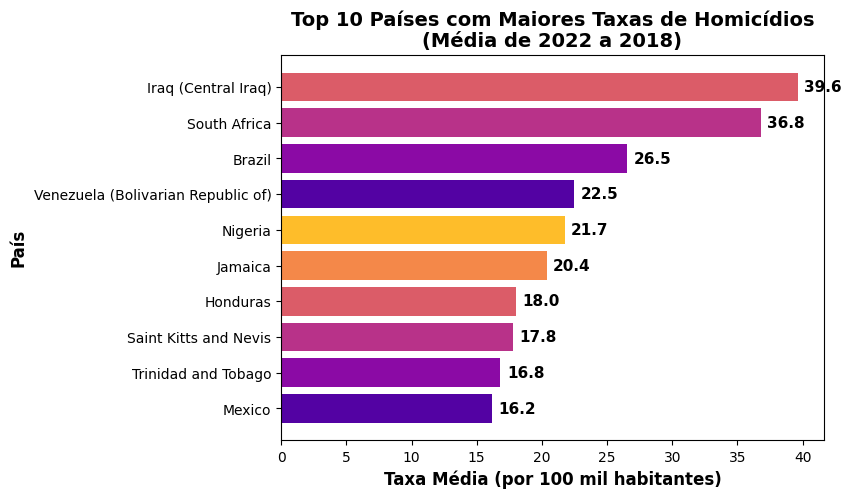

In [ ]:
# Configuração Visual
fig, ax = plt.subplots(figsize=(7, 5))

#Criando Gráfico em Barras Horizontais
df_grafico = df_top_10.sort_values(by='VALUE', ascending=True)
barras = plt.barh(df_grafico['Country'], df_grafico['VALUE'], color=sns.color_palette('plasma'))

# Adicionando Títulos e Rótulos
plt.title(f'Top 10 Países com Maiores Taxas de Homicídios\n(Média de {ano_atual} a {(ano_atual - 4)})', fontsize=14, fontweight='bold', color='black')
plt.xlabel('Taxa Média (por 100 mil habitantes)', fontsize=12, fontweight='bold')
plt.ylabel('País', fontsize=12, fontweight='bold')

# Adicionar 'VALUE' em cada barra
for indice, valor in enumerate(df_grafico['VALUE']):
    plt.text(valor + 0.5, indice, f'{valor:.1f}', va='center', fontsize=11, fontweight='bold')

# Exibe o gráfico
plt.show()


#02. Quais países apresentam os 10 maiores índices de homicídios de mulheres em 2022 ?

In [40]:
# Filtro refinado: Ano 2022, Sexo Feminino, Idade Total, Indicador Vítimas de homicídio Intencional e Dimensão Total
homicidio_mulheres = (
    (novo_df['Year'] == 2022) &
    (novo_df['Sex'] == 'Female') &
    (novo_df['Age'] == 'Total') &
    (novo_df['Unit of measurement'] == 'Rate per 100,000 population') &
    (novo_df['Indicator'] == 'Victims of intentional homicide') &
    (novo_df['Dimension'] == 'Total')
)

df_homicidio_mulheres = novo_df[homicidio_mulheres].copy()
df_homicidio_mulheres = df_homicidio_mulheres.drop_duplicates(subset=['Country'])

display(df_homicidio_mulheres)

,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE
70389,Albania,Europe,Southern Europe,Victims of intentional homicide,Total,Total,Female,Total,2022,"Rate per 100,000 population",0.070200
70390,Argentina,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Female,Total,2022,"Rate per 100,000 population",1.510028
70391,Antigua and Barbuda,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Female,Total,2022,"Rate per 100,000 population",2.041608
70392,Australia,Oceania,Australia and New Zealand,Victims of intentional homicide,Total,Total,Female,Total,2022,"Rate per 100,000 population",0.508382
70393,Austria,Europe,Western Europe,Victims of intentional homicide,Total,Total,Female,Total,2022,"Rate per 100,000 population",0.903400
...,...,...,...,...,...,...,...,...,...,...,...
70451,Türkiye,Asia,Western Asia,Victims of intentional homicide,Total,Total,Female,Total,2022,"Rate per 100,000 population",1.094441
70452,Uruguay,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Female,Total,2022,"Rate per 100,000 population",2.720438
70453,United States of America,Americas,Northern America,Victims of intentional homicide,Total,Total,Female,Total,2022,"Rate per 100,000 population",2.755988
70454,Saint Vincent and the Grenadines,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Female,Total,2022,"Rate per 100,000 population",9.800174


In [ ]:
# Ordenando o DataFrame pelo VALUE do maior para o menor
df_ordenado = df_homicidio_mulheres.sort_values(by='VALUE', ascending=False)

# Pegando as 10 primeiras linhas (que agora são os maiores valores)
df_homicidio_mulheres_2022 = df_ordenado.head(10)

display(df_homicidio_mulheres_2022)

,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE
70425,Saint Lucia,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Female,Total,2022,"Rate per 100,000 population",9.900010
70454,Saint Vincent and the Grenadines,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Female,Total,2022,"Rate per 100,000 population",9.800174
70421,Jamaica,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Female,Total,2022,"Rate per 100,000 population",8.701764
70431,Mexico,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Female,Total,2022,"Rate per 100,000 population",6.014469
70395,Bahamas,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Female,Total,2022,"Rate per 100,000 population",4.669264
70409,Ecuador,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Female,Total,2022,"Rate per 100,000 population",4.647089
70397,Belize,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Female,Total,2022,"Rate per 100,000 population",4.465936
70428,Latvia,Europe,Northern Europe,Victims of intentional homicide,Total,Total,Female,Total,2022,"Rate per 100,000 population",4.031317
70403,Colombia,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Female,Total,2022,"Rate per 100,000 population",3.810115
70447,Suriname,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Female,Total,2022,"Rate per 100,000 population",3.221489


In [ ]:
# Mostrando a tabela com as colunas e linhas importantes.
df_homicidio_mulheres_2022[['Country', 'VALUE']].head(10)

,Country,VALUE
70425,Saint Lucia,9.900010
70454,Saint Vincent and the Grenadines,9.800174
70421,Jamaica,8.701764
70431,Mexico,6.014469
70395,Bahamas,4.669264
70409,Ecuador,4.647089
70397,Belize,4.465936
70428,Latvia,4.031317
70403,Colombia,3.810115
70447,Suriname,3.221489


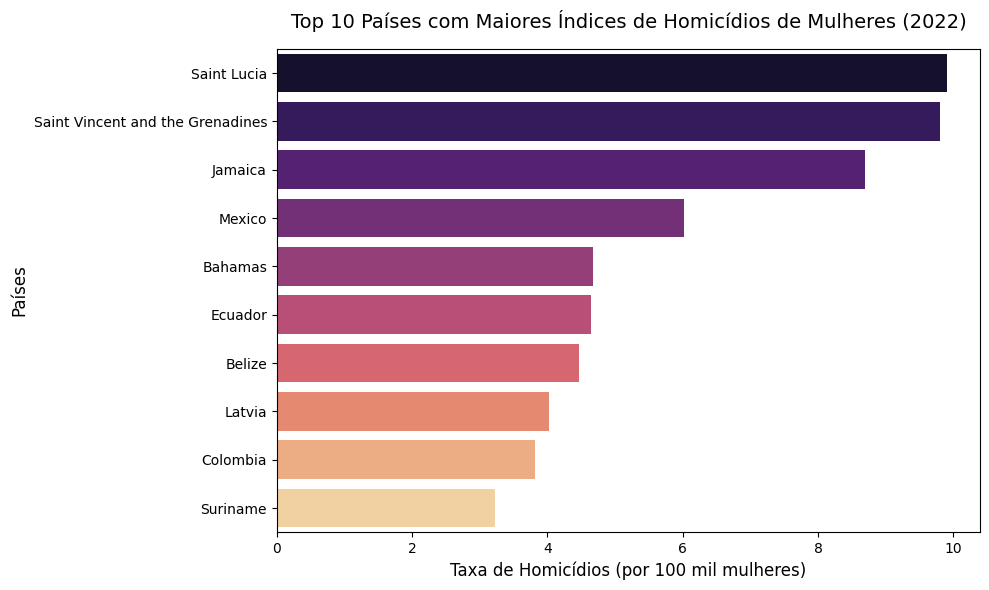

In [ ]:
# Configurando o tamanho da imagem
plt.figure(figsize=(10, 6))

# Criando o gráfico de barras
sns.barplot(
    x='VALUE',
    y='Country',
    data=df_homicidio_mulheres_2022,
    palette='magma',
    hue='Country',
    legend=False
)

plt.locator_params(axis='x', nbins=6)

# Adicionando títulos e rótulos relevantes.
plt.title('Top 10 Países com Maiores Índices de Homicídios de Mulheres (2022)', fontsize=14, pad=15)
plt.xlabel('Taxa de Homicídios (por 100 mil mulheres)', fontsize=12)
plt.ylabel('Países', fontsize=12)

# Exibindo o gráfico limpo
plt.tight_layout()
plt.show()

# 03. Quais as regiões com mais homicídios?

--- Top 10 Regiões com maior Número de Homicídios ---


,Region,VALUE
1,Americas,1.371080e+07
2,Asia,4.825398e+06
3,Europe,3.006971e+06
0,Africa,1.423966e+06
4,Oceania,4.147845e+04


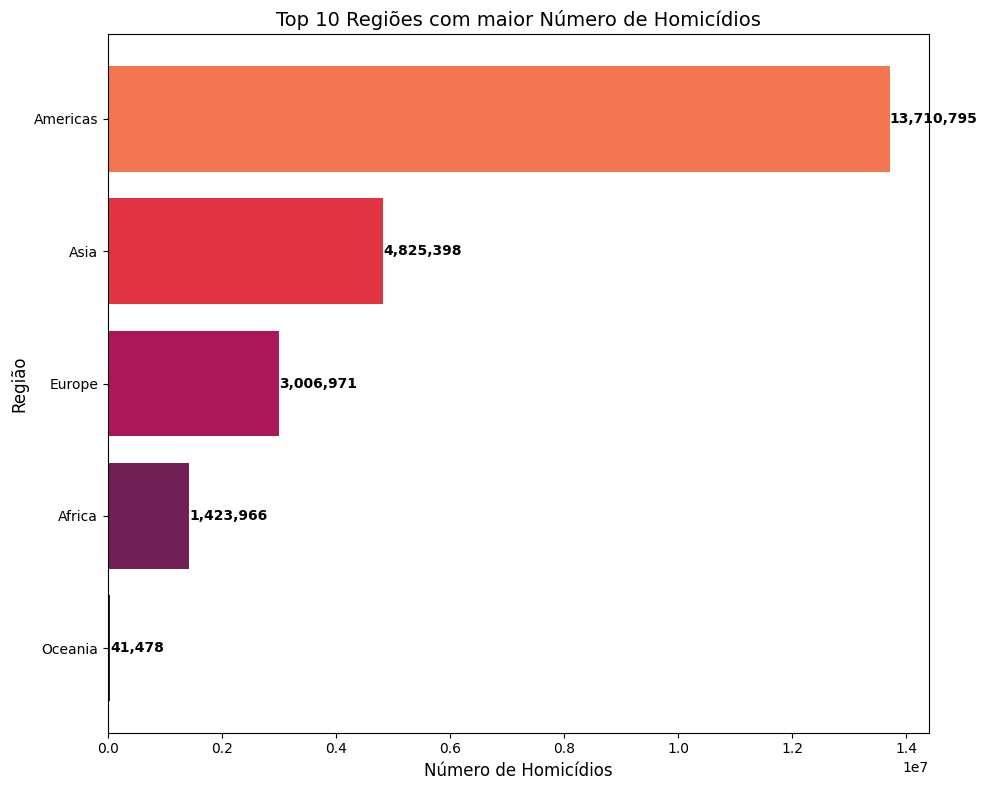

In [ ]:
# Filtrando dados para contagens de vítimas de homicídio intencional
df_regioes = novo_df[
    (novo_df['Indicator'] == 'Victims of intentional homicide') &
    (novo_df['Unit of measurement'] == 'Counts')
].copy()

# Agrupar por 'Region' e somar os valores de 'VALUE'
df_homicidios_por_regiao = df_regioes.groupby('Region')['VALUE'].sum().reset_index()

# Ordenar os dados em ordem decrescente e pegar as top 10 regiões
df_top_10_regioes = df_homicidios_por_regiao.sort_values(by='VALUE', ascending=False).head(10)

# Exibir os dados
print("--- Top 10 Regiões com maior Número de Homicídios ---")
display(df_top_10_regioes)

# Gerando o gráfico
plt.figure(figsize=(10, 8), facecolor='white')
ax = plt.axes()
ax.set_facecolor('white')

# Plotando gráfico de barras horizontais
df_top_10_regioes_plot = df_top_10_regioes.sort_values(by='VALUE', ascending=True)
plt.barh(df_top_10_regioes_plot['Region'], df_top_10_regioes_plot['VALUE'], color=sns.color_palette('rocket'))

# Adicionando títulos e rótulos
plt.title("Top 10 Regiões com maior Número de Homicídios", fontsize=14)
plt.xlabel('Número de Homicídios', fontsize=12)
plt.ylabel('Região', fontsize=12)

# Adicionando a quantidade de homicídios em cada barra
for indice, valor in enumerate(df_top_10_regioes_plot['VALUE']):
    plt.text(valor + 0.2, indice, f'{valor:,.0f}', va='center', fontsize=10, fontweight='bold')

# Mostrando o gráfico
plt.tight_layout()
plt.show()

# 04. Quais países com menor número de homicídios em cada subregião?

In [ ]:
# Filtrando Dados para Contagens de Vítimas de Homicídio Intencional
df_homicidios_subregiao = novo_df[
    (novo_df['Indicator'] == 'Victims of intentional homicide') &
    (novo_df['Unit of measurement'] == 'Counts')
].copy()

# Agrupar por 'Subregion' e 'Country' e somar os valores de 'VALUE'
df_homicidios_por_pais_subregiao = df_homicidios_subregiao.groupby(['Subregion', 'Country'])['VALUE'].sum().reset_index()

# Encontrar o país com o menor número de homicídios em cada sub-região
id_menor_homicidio = df_homicidios_por_pais_subregiao.groupby('Subregion')['VALUE'].idxmin()
df_menor_homicidio_por_subregiao = df_homicidios_por_pais_subregiao.loc[id_menor_homicidio].sort_values(by='VALUE', ascending=True)

# Exibir os resultados
print("--- Países com o Menor Número de Homicídios por Sub-Região ---")
display(df_menor_homicidio_por_subregiao)


--- Países com o Menor Número de Homicídios por Sub-Região ---


,Subregion,Country,VALUE
131,Southern Europe,Holy See,0.000000
101,Polynesia,Cook Islands,0.628095
166,Sub-Saharan Africa,Saint Helena,1.000000
202,Western Europe,Monaco,1.000000
85,Northern America,Saint Pierre and Miquelon,2.000000
76,Micronesia,Micronesia (Federated States of),2.000000
72,Melanesia,Vanuatu,8.000000
92,Northern Europe,Isle of Man,9.000000
52,Latin America and the Caribbean,Montserrat,18.000000
106,South-eastern Asia,Brunei Darussalam,83.000000


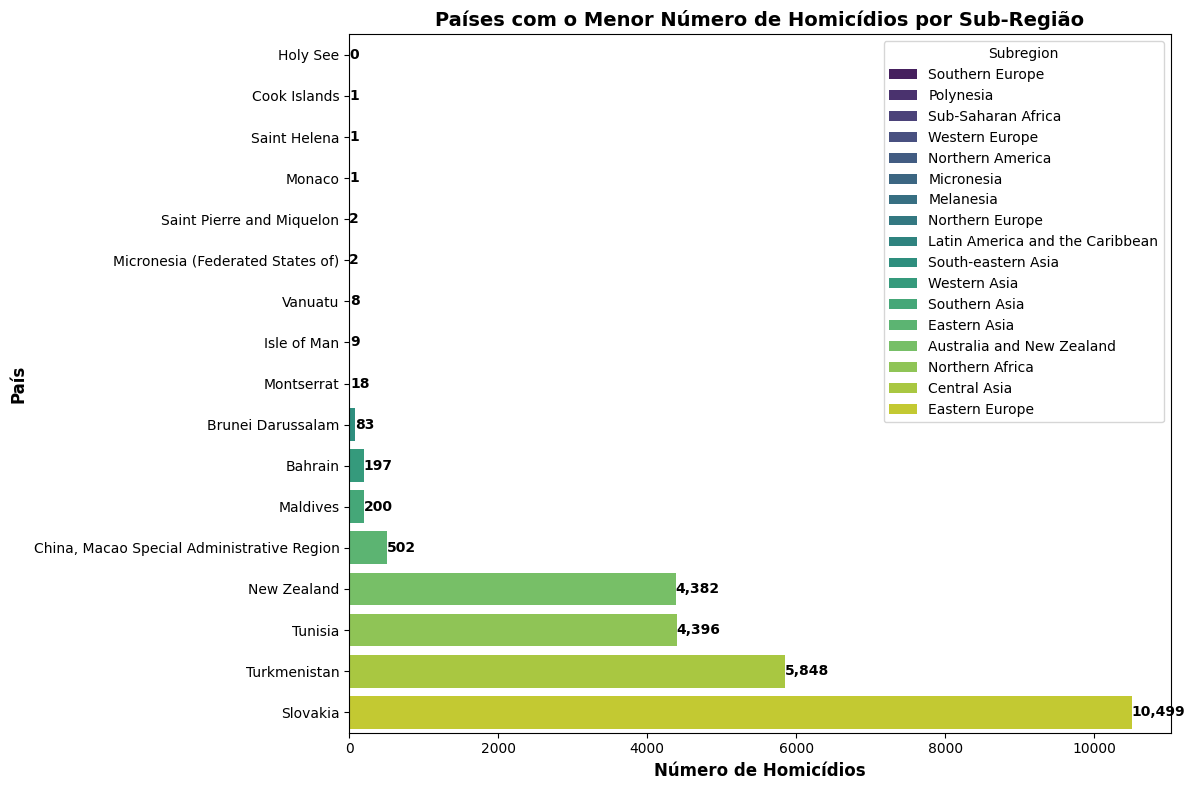

In [ ]:
# Gerando o gráfico
plt.figure(figsize=(12, 8), facecolor='white')
ax = plt.axes()
ax.set_facecolor('white')

# Plotando Gráfico de Barras Horizontais
sns.barplot(
    x='VALUE',
    y='Country',
    hue='Subregion',
    data=df_menor_homicidio_por_subregiao,
    palette='viridis',
    dodge=False
)

# Adicionando Títulos e Rótulos
plt.title('Países com o Menor Número de Homicídios por Sub-Região', fontsize=14, fontweight='bold')
plt.xlabel('Número de Homicídios', fontsize=12, fontweight='bold')
plt.ylabel('País', fontsize=12, fontweight='bold')

# Adicionando a quantidade de homicídios em cada barra
for index, value in enumerate(df_menor_homicidio_por_subregiao['VALUE']):
    plt.text(value + 0.2, index, f'{value:,.0f}', va='center', fontsize=10, fontweight='bold')

# Mostrando o Gráfico
plt.tight_layout()
plt.show()

# 05. Quais países com menor número de morte de mulheres?

In [ ]:
# Filtrando os dados para mortes de mulheres (todos os anos).
mortes_mulheres = (
    (novo_df['Sex'] == 'Female') &
    (novo_df['Age'] == 'Total') &
    (novo_df['Unit of measurement'] == 'Counts') &
    (novo_df['Indicator'] == 'Victims of intentional homicide') &
    (novo_df['Dimension'] == 'Total')
)

df_mortes_mulheres = novo_df[mortes_mulheres].copy()

# Agrupando por país e calculando a soma dos 'VALUE' ao longo dos anos.
df_mortes_mulheres_por_pais = df_mortes_mulheres.groupby('Country')['VALUE'].sum().reset_index()

# Ordenando o DataFrame pela média do VALUE do menor para o maior
df_menores_mortes_mulheres = df_mortes_mulheres_por_pais.sort_values(by='VALUE', ascending=True)

# Pegando as 10 primeiras linhas (que agora são as menores médias de valores)
df_top10_menores_mortes_mulheres = df_menores_mortes_mulheres.head(10)

display(df_top10_menores_mortes_mulheres[['Country', 'VALUE']])

,Country,VALUE
63,Holy See,0.0
125,Sao Tome and Principe,0.0
121,Saint Pierre and Miquelon,0.0
93,Monaco,0.0
92,Micronesia (Federated States of),1.0
5,Anguilla,1.0
4,Andorra,1.0
124,San Marino,1.0
96,Montserrat,2.0
123,Samoa,2.0


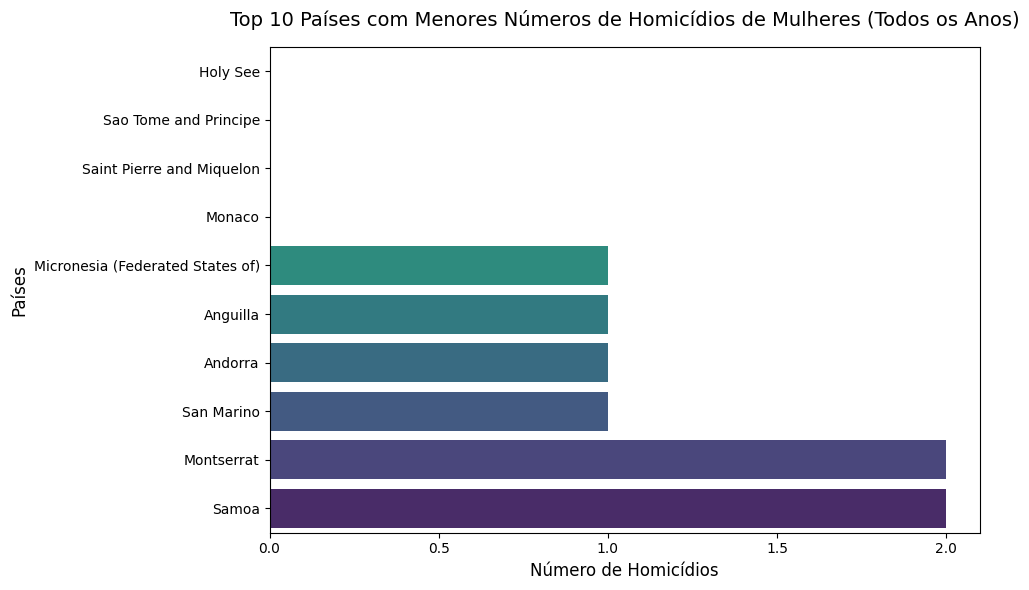

In [ ]:
# Configurando o tamanho da imagem
plt.figure(figsize=(10, 6))

# Criando o gráfico de barras
sns.barplot(
    x='VALUE',
    y='Country',
    data=df_top10_menores_mortes_mulheres,
    palette='viridis_r',
    hue='Country',
    legend=False
)

plt.locator_params(axis='x', nbins=6)

# Adicionando títulos e rótulos relevantes.
plt.title('Top 10 Países com Menores Números de Homicídios de Mulheres (Todos os Anos)', fontsize=14, pad=15)
plt.xlabel('Número de Homicídios', fontsize=12)
plt.ylabel('Países', fontsize=12)

# Exibindo o gráfico limpo
plt.tight_layout()
plt.show()

# 06. Quais as subregiões com maior número de homicídios?

In [ ]:
# Filtrando Dados para Counts
df_sub = (
    (novo_df['Indicator'] == 'Victims of intentional homicide') &
    (novo_df['Unit of measurement'] == 'Counts')
)

df_sub = novo_df[df_sub].copy()

df_taxa = df_sub[df_sub['Unit of measurement'] == 'Counts']

# Agrupar 'Subregion' pela soma de 'VALUE'
df_subregiao = df_sub.groupby(['Subregion'])['VALUE'].sum().reset_index()

# Colocar dados em Ordem Decrescente
df_top_10_subregiao = df_subregiao.sort_values(by='VALUE', ascending=False).head(10)

# Exibir os dados
display(df_top_10_subregiao)


,Subregion,VALUE
4,Latin America and the Caribbean,1.145862e+07
12,Southern Asia,3.099440e+06
3,Eastern Europe,2.428605e+06
8,Northern America,2.252174e+06
14,Sub-Saharan Africa,1.293510e+06
11,South-eastern Asia,6.649834e+05
15,Western Asia,5.186620e+05
2,Eastern Asia,4.267797e+05
16,Western Europe,2.371376e+05
13,Southern Europe,1.853255e+05


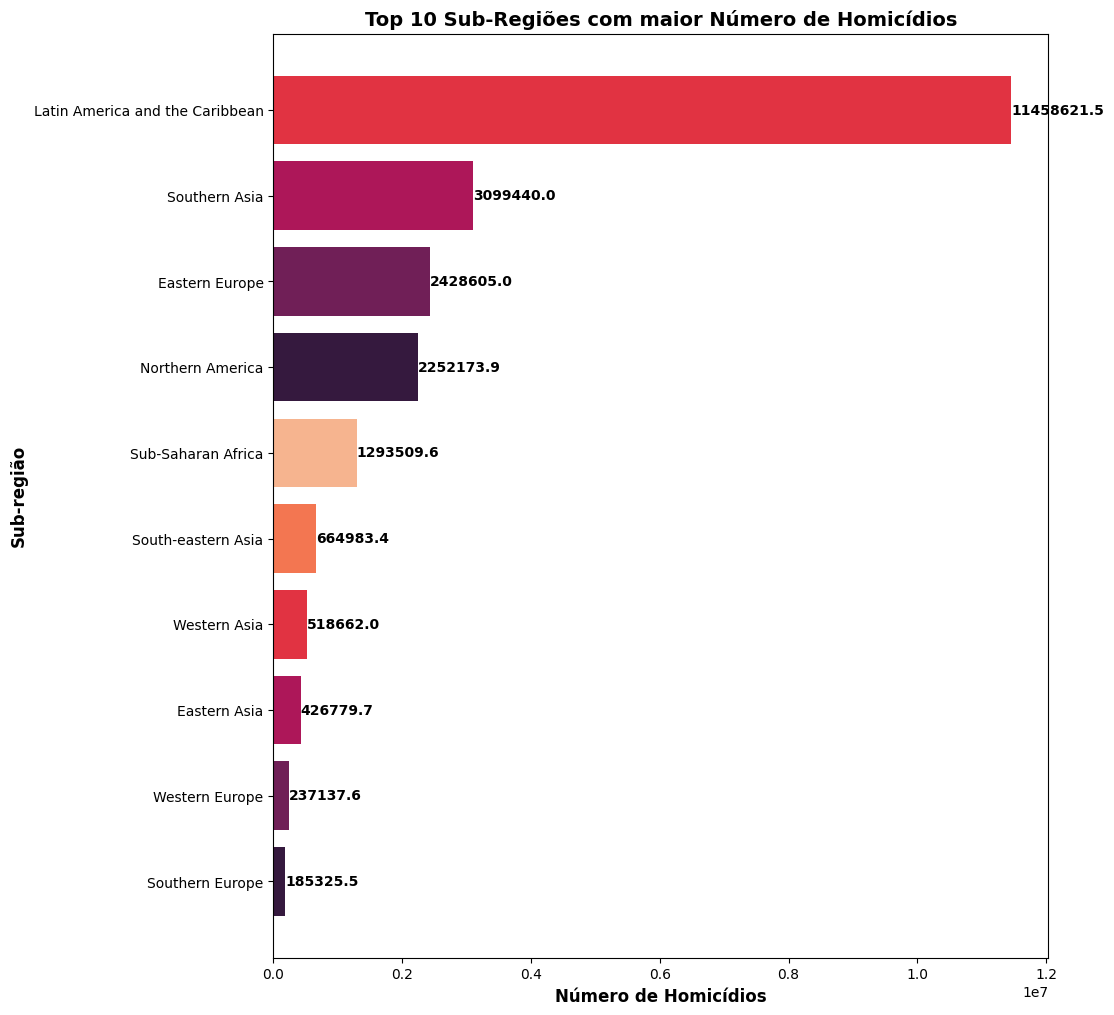

In [ ]:
# Gerando o gráfico
plt.figure(figsize=(10, 12), facecolor='white')
ax = plt.axes()
ax.set_facecolor('white')

# Plotando Gráfico de Barras Horizontais
df_top_10_subregiao = df_top_10_subregiao.sort_values(by='VALUE', ascending=True)
plt.barh(df_top_10_subregiao['Subregion'], df_top_10_subregiao['VALUE'], color= sns.color_palette('rocket'))

# Adicionando Títulos e Marcações
plt.title("Top 10 Sub-Regiões com maior Número de Homicídios", fontsize=14, fontweight='bold')
plt.xlabel('Número de Homicídios', fontsize=12, fontweight='bold')
plt.ylabel('Sub-região', fontsize=12, fontweight='bold')

# Adicionando a quantidade de homicídios
for indice, valor in enumerate(df_top_10_subregiao['VALUE']):
    plt.text(valor + 0.2, indice, f'{valor:.1f}', va='center', fontsize=10, fontweight='bold')

# Mostrando o Gráfico
plt.show()

# 07. Identifique o país com maior número de homicídios em cada continente em 2020

In [ ]:
# Filtrando os dados para mortes em cada continente em 2020.
homicidio_continentes = (
    (novo_df['Year'] == 2020) &
    (novo_df['Sex'] == 'Total') &
    (novo_df['Age'] == 'Total') &
    (novo_df['Unit of measurement'] == 'Counts') &
    (novo_df['Indicator'] == 'Victims of intentional homicide') &
    (novo_df['Dimension'] == 'Total')
)

df_homicidio_continentes = novo_df[homicidio_continentes].copy()

# Encontrando o país com o maior número de homicídios por continente em 2020
paises_homicidio_continente = df_homicidio_continentes.loc[df_homicidio_continentes.groupby('Region')['VALUE'].idxmax()]

df_homicidio_continente_2020 = paises_homicidio_continente.sort_values(by='VALUE', ascending=False)

display(df_homicidio_continente_2020[['Region', 'Country', 'VALUE']])

,Region,Country,VALUE
5163,Americas,Brazil,47722.0
5203,Asia,India,40651.0
5275,Africa,South Africa,19972.0
5249,Europe,Russian Federation,10697.0
5153,Oceania,Australia,221.0


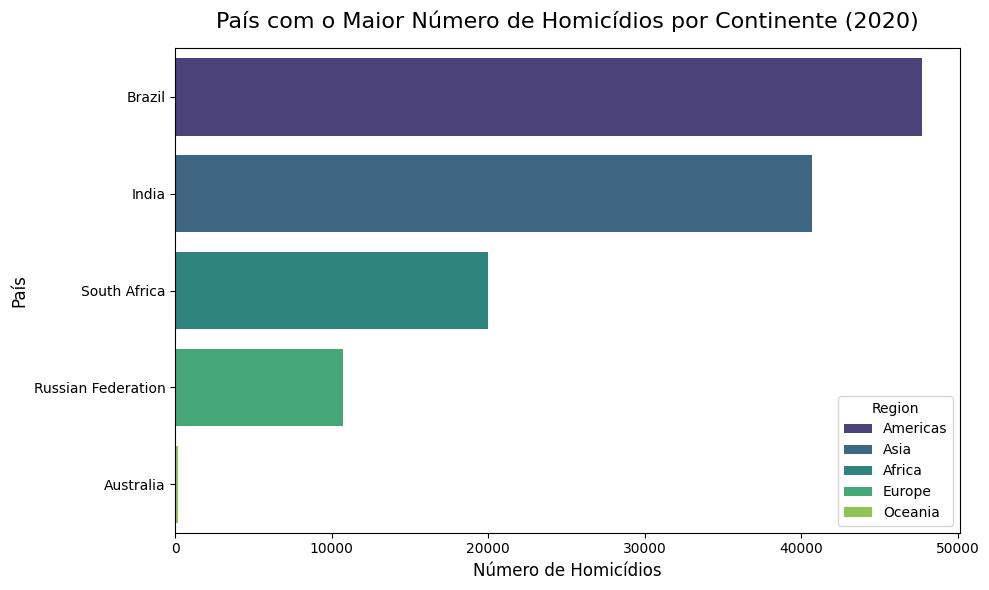

In [ ]:
# Configurando o tamanho da imagem
plt.figure(figsize=(10, 6))

# Criando o gráfico de barras
sns.barplot(
    x='VALUE',
    y='Country',
    data=df_homicidio_continente_2020,
    palette='viridis',
    hue='Region',
    dodge=False,
    legend='full'
)

plt.locator_params(axis='x', nbins=6)

# Adicionando títulos e rótulos relevantes.
plt.title('País com o Maior Número de Homicídios por Continente (2020)', fontsize=16, pad=15)
plt.xlabel('Número de Homicídios', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Exibindo o gráfico limpo
plt.tight_layout()
plt.show()

# 08. Qual o país mais violento para as mulheres em 2021?

In [ ]:
# Filtrando os dados para homicídios de mulheres em 2021
homicidios_mulheres_2021 = (
    (novo_df['Year'] == 2021) &
    (novo_df['Sex'] == 'Female') &
    (novo_df['Age'] == 'Total') &
    (novo_df['Unit of measurement'] == 'Rate per 100,000 population') &
    (novo_df['Indicator'] == 'Victims of intentional homicide') &
    (novo_df['Dimension'] == 'Total')
)

df_mulheres_2021 = novo_df[homicidios_mulheres_2021].copy()

# Encontrando o país com o maior 'VALUE' (taxa de homicídios)
pais_mais_violento = df_mulheres_2021.loc[df_mulheres_2021['VALUE'].idxmax()]

print("--- País Mais Violento para Mulheres em 2021 ---")
display(pais_mais_violento[['Country', 'VALUE']])

--- País Mais Violento para Mulheres em 2021 ---


,70292
Country,Antigua and Barbuda
VALUE,10.265149


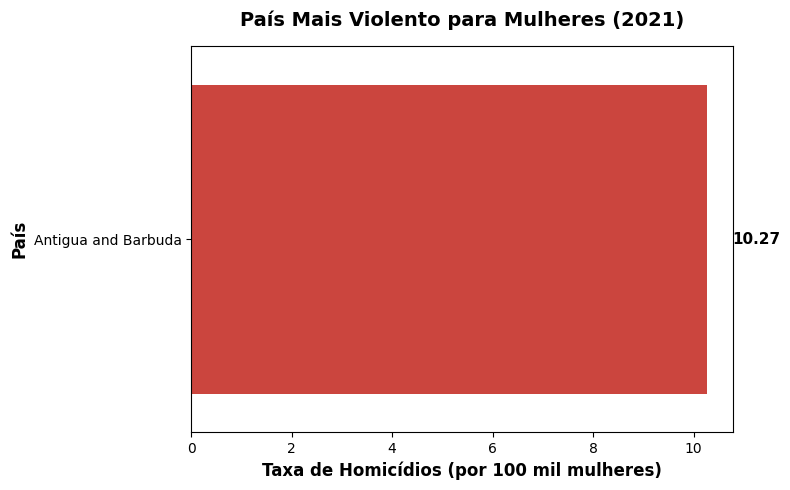

In [ ]:
# Gerando o gráfico para o país mais violento para mulheres em 2021
plt.figure(figsize=(8, 5), facecolor='white')
ax = plt.axes()
ax.set_facecolor('white')

sns.barplot(
    x=[pais_mais_violento['VALUE']],
    y=[pais_mais_violento['Country']],
    palette='Reds_d',
    hue=[pais_mais_violento['Country']],
    legend=False
)

plt.title('País Mais Violento para Mulheres (2021)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Taxa de Homicídios (por 100 mil mulheres)', fontsize=12, fontweight='bold')
plt.ylabel('País', fontsize=12, fontweight='bold')

# Adicionando o valor na barra
plt.text(pais_mais_violento['VALUE'] + 0.5, 0, f'{pais_mais_violento['VALUE']:.2f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 09. Qual o país com maior valor de 'indicador: Victims of intentional homicide'?

In [ ]:
homicidio_intencional= (
    (novo_df['Sex'] == 'Total') &
    (novo_df['Age'] == 'Total') &
    (novo_df['Unit of measurement'] == 'Rate per 100,000 population') &
    (novo_df['Indicator'] == 'Victims of intentional homicide') &
    (novo_df['Dimension'] == 'Total')
)

df_homicidio_intencional = novo_df[homicidio_intencional].copy()
df_homicidio_intencional = df_homicidio_intencional.drop_duplicates(subset=['Country'])

display(df_homicidio_intencional)

,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE
60888,Aruba,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,1990,"Rate per 100,000 population",0.000000
60889,Anguilla,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,1990,"Rate per 100,000 population",0.000000
60890,Armenia,Asia,Western Asia,Victims of intentional homicide,Total,Total,Total,Total,1990,"Rate per 100,000 population",5.004864
60891,Antigua and Barbuda,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,1990,"Rate per 100,000 population",1.579080
60892,Australia,Oceania,Australia and New Zealand,Victims of intentional homicide,Total,Total,Total,Total,1990,"Rate per 100,000 population",2.193805
...,...,...,...,...,...,...,...,...,...,...,...
64243,Guinea-Bissau,Africa,Sub-Saharan Africa,Victims of intentional homicide,Total,Total,Total,Total,2016,"Rate per 100,000 population",3.488590
64285,Nigeria,Africa,Sub-Saharan Africa,Victims of intentional homicide,Total,Total,Total,Total,2016,"Rate per 100,000 population",33.604193
64541,Mauritania,Africa,Sub-Saharan Africa,Victims of intentional homicide,Total,Total,Total,Total,2018,"Rate per 100,000 population",1.241011
64629,Micronesia (Federated States of),Oceania,Micronesia,Victims of intentional homicide,Total,Total,Total,Total,2019,"Rate per 100,000 population",0.897839


In [ ]:
df_homicidio_intencional_ordenado = df_homicidio_intencional.sort_values(by='VALUE', ascending=False)
df_homicidio_intencional_top10 = df_homicidio_intencional_ordenado.head(10)

display(df_homicidio_intencional_top10)

,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE
61358,El Salvador,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,1994,"Rate per 100,000 population",134.778654
60906,Colombia,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,1990,"Rate per 100,000 population",74.628713
61374,South Africa,Africa,Sub-Saharan Africa,Victims of intentional homicide,Total,Total,Total,Total,1994,"Rate per 100,000 population",60.009732
64285,Nigeria,Africa,Sub-Saharan Africa,Victims of intentional homicide,Total,Total,Total,Total,2016,"Rate per 100,000 population",33.604193
62481,French Guiana,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,2004,"Rate per 100,000 population",29.944216
60939,Lesotho,Africa,Sub-Saharan Africa,Victims of intentional homicide,Total,Total,Total,Total,1990,"Rate per 100,000 population",28.849409
61696,United States Virgin Islands,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,1997,"Rate per 100,000 population",28.359408
61114,Guatemala,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,1992,"Rate per 100,000 population",27.869926
61113,Greenland,Americas,Northern America,Victims of intentional homicide,Total,Total,Total,Total,1992,"Rate per 100,000 population",23.344557
61449,Namibia,Africa,Sub-Saharan Africa,Victims of intentional homicide,Total,Total,Total,Total,1995,"Rate per 100,000 population",23.234505


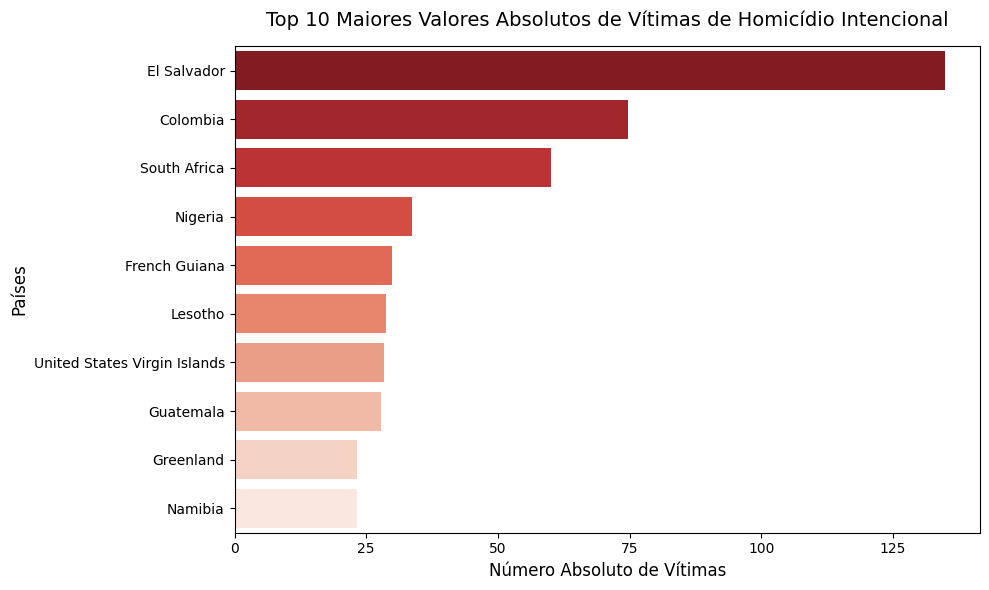

In [ ]:
df_homicidio_intencional_top10[['Country', 'VALUE']].head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x='VALUE',
    y='Country',
    data=df_homicidio_intencional_top10,
    palette='Reds_r',
    hue='Country',
    legend=False
)

plt.locator_params(axis='x', nbins=6)

plt.title("Top 10 Maiores Valores Absolutos de Vítimas de Homicídio Intencional", fontsize=14, pad=15)
plt.xlabel("Número Absoluto de Vítimas", fontsize=12)
plt.ylabel("Países", fontsize=12)

plt.tight_layout()
plt.show()

# 10. Qual a média de homicídios no Brasil nos últimos 10 anos?

In [33]:
filtro_brasil = (
    (novo_df['Country'] == 'Brazil') &
    (novo_df['Year'] >= 2013) &
    (novo_df['Year'] <= 2022) &
    (novo_df['Indicator'] == 'Victims of intentional homicide') &
    (novo_df['Sex'] == 'Total') &
    (novo_df['Age'] == 'Total') &
    (novo_df['Dimension'] == 'Total') &
    (novo_df['Unit of measurement'] == 'Rate per 100,000 population')
)

df_brasil_10anos = novo_df[filtro_brasil].copy()

display(df_brasil_10anos)

,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE
63816,Brazil,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,2013,"Rate per 100,000 population",28.179904
63951,Brazil,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,2014,"Rate per 100,000 population",29.358647
64082,Brazil,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,2015,"Rate per 100,000 population",28.356406
64212,Brazil,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,2016,"Rate per 100,000 population",29.589154
64343,Brazil,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,2017,"Rate per 100,000 population",30.593037
64474,Brazil,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,2018,"Rate per 100,000 population",26.636013
64605,Brazil,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,2019,"Rate per 100,000 population",20.810464
64741,Brazil,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,2020,"Rate per 100,000 population",22.384065
64872,Brazil,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,2021,"Rate per 100,000 population",21.258248


In [ ]:
media_br = df_brasil_10anos['VALUE'].mean()
print(f"A média da taxa de homicídios no Brasil (2013-2022) é: {media_br:.2f} por 100 mil habitantes.\n")

A média da taxa de homicídios no Brasil (2013-2022) é: 26.54 por 100 mil habitantes.



In [34]:
df_brasil_ordenado = df_brasil_10anos.sort_values(by='Year', ascending=True)
df_brasil_ordenado['Year'] = df_brasil_ordenado['Year'].astype(str)

print("Taxas anuais do Brasil ordenadas:")
display(df_brasil_ordenado[['Year', 'VALUE']])

Taxas anuais do Brasil ordenadas:


,Year,VALUE
63816,2013,28.179904
63951,2014,29.358647
64082,2015,28.356406
64212,2016,29.589154
64343,2017,30.593037
64474,2018,26.636013
64605,2019,20.810464
64741,2020,22.384065
64872,2021,21.258248


In [37]:
df_teste_2022 = novo_df[(novo_df['Country'] == 'Brazil') & (novo_df['Year'] == 2021)]

print(f"Quantidade de registros encontrados para o Brasil em 2022: {len(df_teste_2022)}")

display(df_teste_2022)

Quantidade de registros encontrados para o Brasil em 2022: 6


,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE
5294,Brazil,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,2021,Counts,45562.000000
8024,Brazil,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Male,Total,2021,Counts,41644.000000
10741,Brazil,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Female,Total,2021,Counts,3844.000000
64872,Brazil,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,2021,"Rate per 100,000 population",21.258248
67595,Brazil,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Male,Total,2021,"Rate per 100,000 population",39.551229
70303,Brazil,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Female,Total,2021,"Rate per 100,000 population",3.525476


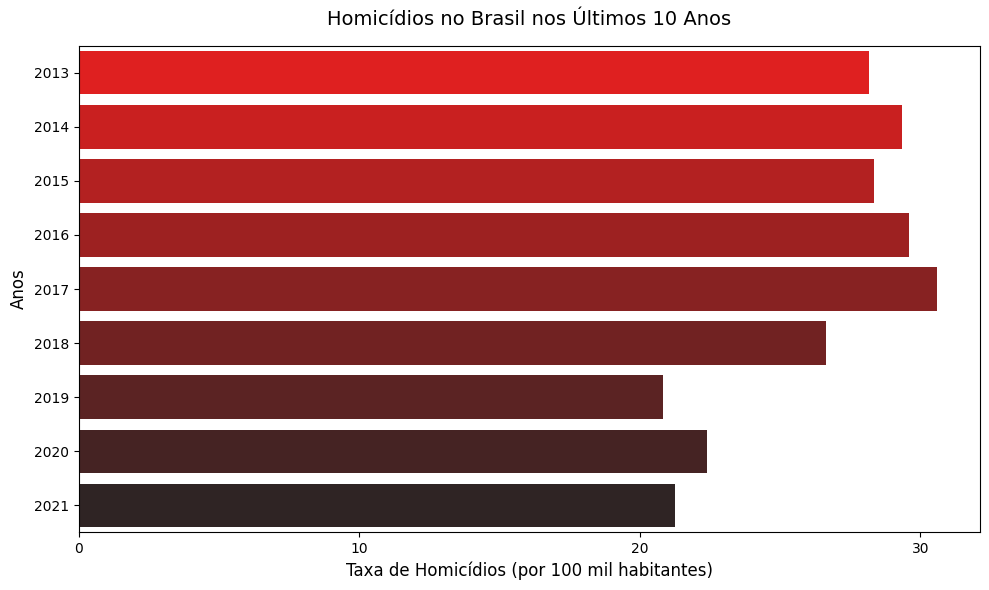

In [35]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='VALUE',
    y='Year',
    data=df_brasil_ordenado,
    palette='dark:red_r',
    hue='Year',
    legend=False
)

plt.locator_params(axis='x', nbins=6)

plt.title("Homicídios no Brasil nos Últimos 10 Anos", fontsize=14, pad=15)
plt.xlabel("Taxa de Homicídios (por 100 mil habitantes)", fontsize=12)
plt.ylabel("Anos", fontsize=12)

plt.tight_layout()
plt.show()